In [1]:
import warnings
warnings.filterwarnings('ignore')
import logging
import lightgbm as lgb

# Suppress LightGBM warnings
logging.getLogger('lightgbm').setLevel(logging.ERROR)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import optuna


In [3]:
print("Loading data...")
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('tested.csv')
train = train_df.copy()
test= test_df.copy()
print(f"Training data shape: {train.shape}")
print(f"Testing data shape: {test.shape}")

Loading data...
Training data shape: (891, 12)
Testing data shape: (418, 12)


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Display first few rows of training data
print("First five rows of the training data:")
display(train.head())

# Display information about the dataset
print("\nDataset Information:")
train.info()

# Check for missing values
print("\nMissing values in training data:")
display(train.isnull().sum())

# Statistical summary
print("\nStatistical summary of numeric features:")
display(train.describe())

First five rows of the training data:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values in training data:


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Statistical summary of numeric features:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
train['Name'].nunique()

891

In [7]:
train.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test.drop(columns= ['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace= True)

In [8]:
train['Age'].fillna(train['Age'].median(), inplace=True)
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

In [9]:
print(train.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [10]:
test['Age'].fillna(test['Age'].median(), inplace=True)
test['Fare'].fillna(test['Fare'].median(), inplace=True)

In [11]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

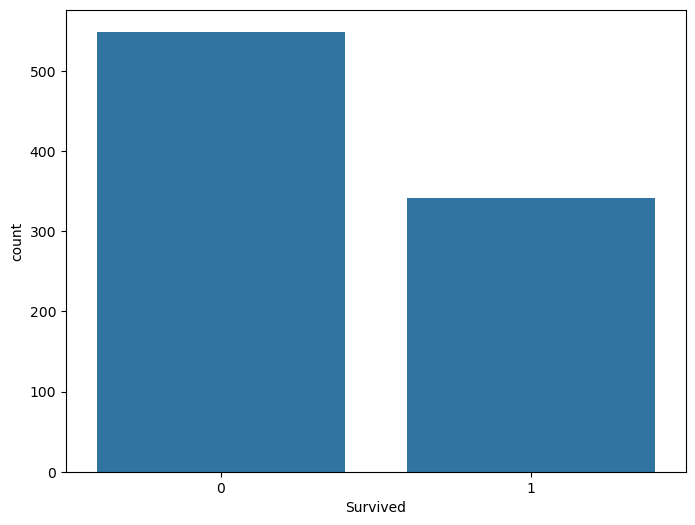

In [12]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data= train)

<Axes: xlabel='Survived', ylabel='count'>

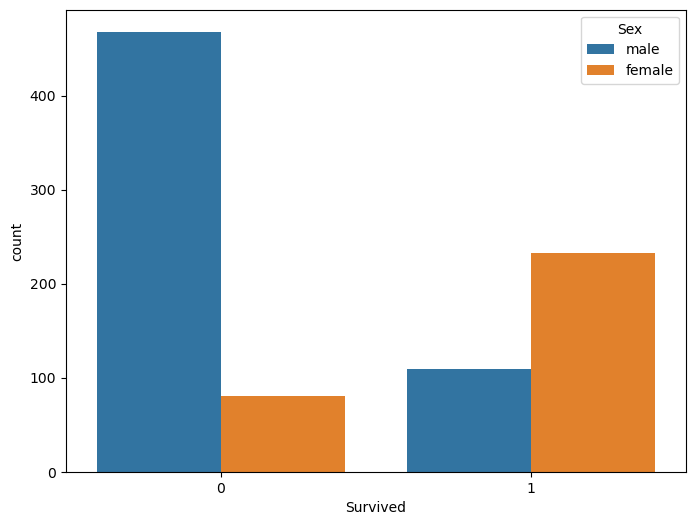

In [13]:
plt.figure(figsize=(8,6))
sns.countplot(x='Survived', hue='Sex', data= train)

<Axes: xlabel='Survived'>

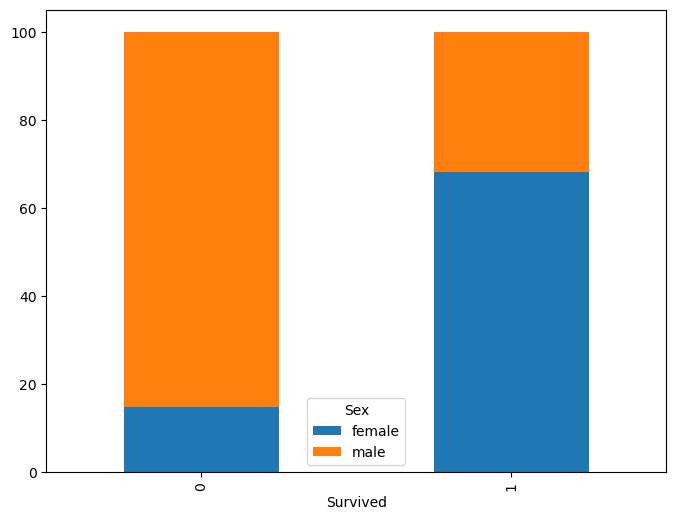

In [14]:
sur_p = train.groupby(['Survived', 'Sex']).size().unstack(fill_value=0)
sur_p_percent = sur_p.div(sur_p.sum(axis=1), axis=0) * 100
sur_p_percent.plot(kind='bar', stacked=True, figsize=(8,6))

<Axes: xlabel='Age', ylabel='Count'>

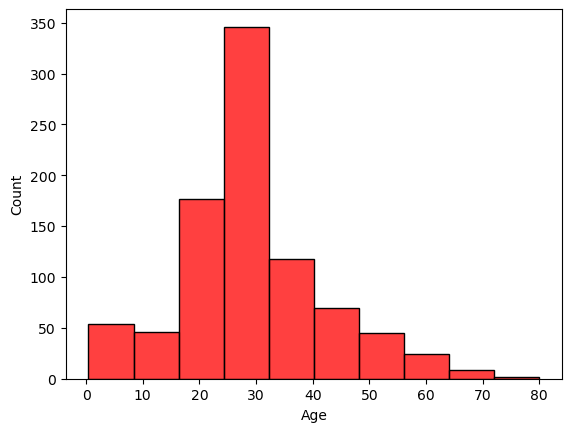

In [15]:
sns.histplot(x='Age', data=train, bins=10, color='red')

<Axes: xlabel='Pclass', ylabel='Fare'>

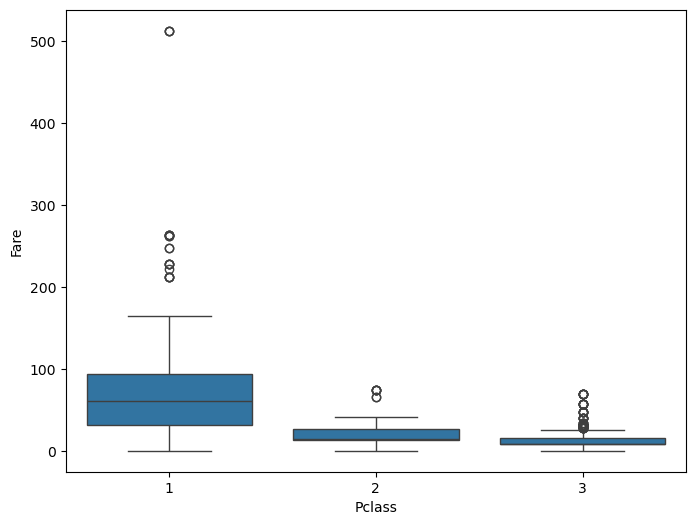

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y= 'Fare', data= train)

In [17]:
cols= ['Age', 'SibSp', 'Parch', 'Fare']

train[cols]= train[cols].clip(lower= train[cols].quantile(0.15), upper= train[cols].quantile(0.85), axis=1)

train.drop(columns=['Parch'], axis=1, inplace=True)

In [18]:
train.select_dtypes(include='number').corr()

,Survived,Pclass,Age,SibSp,Fare
Survived,1.000000,-0.338481,-0.023878,0.115867,0.314835
Pclass,-0.338481,1.000000,-0.333720,-0.076009,-0.726347
Age,-0.023878,-0.333720,1.000000,-0.079553,0.167626
SibSp,0.115867,-0.076009,-0.079553,1.000000,0.394485
Fare,0.314835,-0.726347,0.167626,0.394485,1.000000


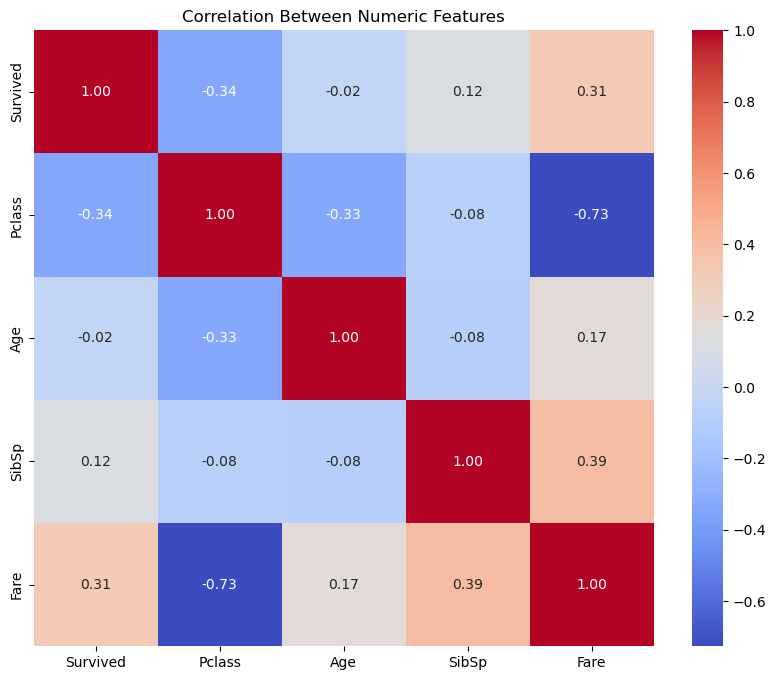

In [19]:
# Correlation heatmap of numeric features
plt.figure(figsize=(10, 8))
numeric_data = train.select_dtypes(include='number')
correlation = numeric_data.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Numeric Features')
plt.savefig('correlation_heatmap.png')
plt.show()


<Axes: >

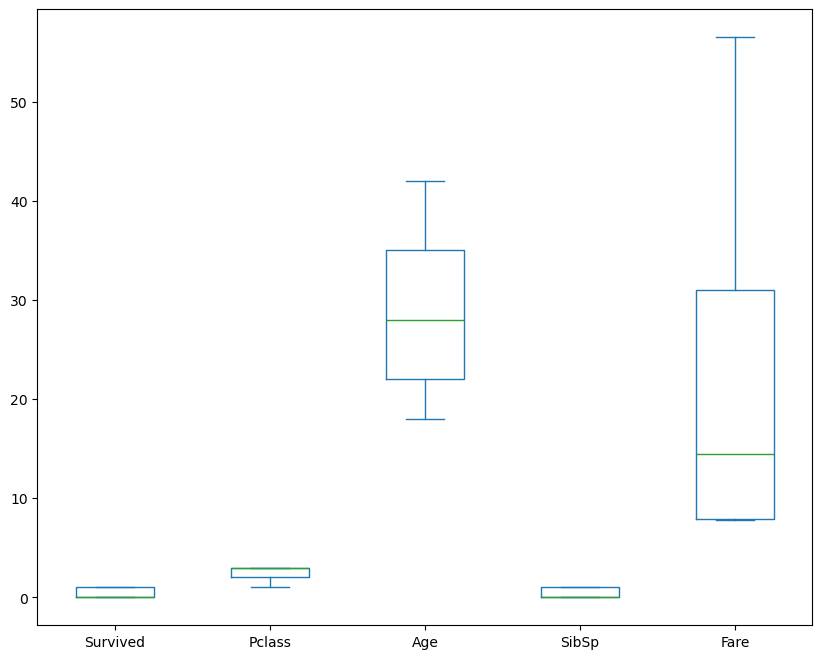

In [20]:
train.plot(kind='box', figsize= (10,8)) 

In [21]:
train_df['set'] = 'train'
test_df['set'] = 'test'
all_df = pd.concat([train_df, test_df], axis=0)

In [22]:
all_df["Family Size"] = all_df["SibSp"] + all_df["Parch"] + 1
all_df["Age Interval"] = 0.0
all_df.loc[ all_df['Age'] <= 16, 'Age Interval']  = 0
all_df.loc[(all_df['Age'] > 16) & (all_df['Age'] <= 32), 'Age Interval'] = 1
all_df.loc[(all_df['Age'] > 32) & (all_df['Age'] <= 48), 'Age Interval'] = 2
all_df.loc[(all_df['Age'] > 48) & (all_df['Age'] <= 64), 'Age Interval'] = 3
all_df.loc[ all_df['Age'] > 64, 'Age Interval'] = 4
all_df['Fare Interval'] = 0.0
all_df.loc[ all_df['Fare'] <= 7.91, 'Fare Interval'] = 0
all_df.loc[(all_df['Fare'] > 7.91) & (all_df['Fare'] <= 14.454), 'Fare Interval'] = 1
all_df.loc[(all_df['Fare'] > 14.454) & (all_df['Fare'] <= 31), 'Fare Interval']   = 2
all_df.loc[ all_df['Fare'] > 31, 'Fare Interval'] = 3
all_df["Sex_Pclass"] = all_df.apply(lambda row: row['Sex'][0].upper() + "_C" + str(row["Pclass"]), axis=1)
def get_deck(text):
    try:
        return text[0]
    except Exception as ex:
        return "Unknown"
    
all_df["Deck"] = all_df["Cabin"].apply(lambda x: get_deck(x))

In [23]:
def parse_names(row):
    try:
        text = row["Name"]
        split_text = text.split(",")
        family_name = split_text[0]
        next_text = split_text[1]
        split_text = next_text.split(".")
        title = (split_text[0] + ".").lstrip().rstrip()
        next_text = split_text[1]
        if "(" in next_text:
            split_text = next_text.split("(")
            given_name = split_text[0]
            maiden_name = split_text[1].rstrip(")")
            return pd.Series([family_name, title, given_name, maiden_name])
        else:
            given_name = next_text
            return pd.Series([family_name, title, given_name, None])
    except Exception as ex:
        print(f"Exception: {ex}")
    
all_df[["Family Name", "Title", "Given Name", "Maiden Name"]] = all_df.apply(lambda row: parse_names(row), axis=1)

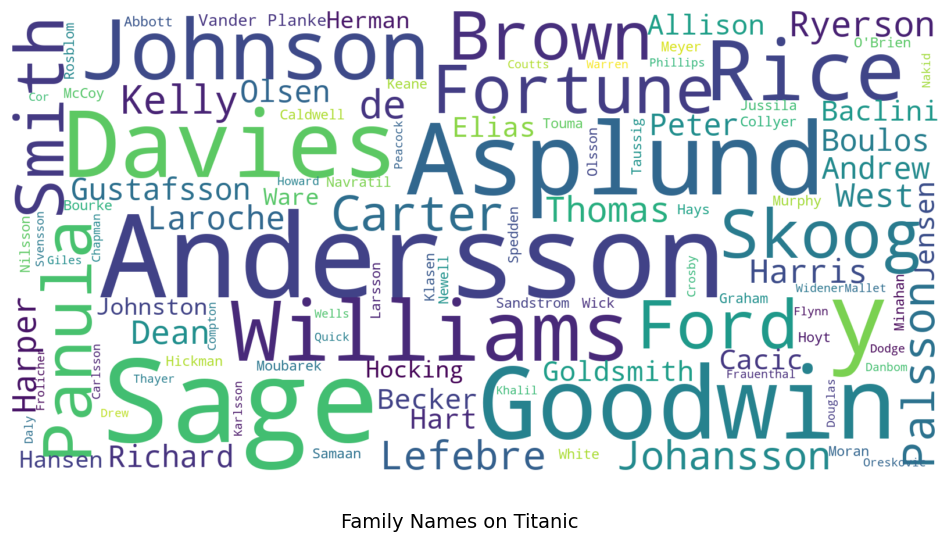

In [24]:
from wordcloud import WordCloud, STOPWORDS
stopwords = set(STOPWORDS)

def show_wordcloud(data, mask=None, title=""):
    text = " ".join(t for t in data.dropna())
    stopwords = set(STOPWORDS)
    stopwords.update(["t", "co", "https", "amp", "U", "Comment", "text", "attr", "object"])
    wordcloud = WordCloud(stopwords=stopwords, scale=4, max_font_size=50, max_words=500,mask=mask, background_color="white").generate(text)
    fig = plt.figure(1, figsize=(12, 12))
    plt.axis('off')
    fig.suptitle(title, fontsize=14)
    fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.show()    
show_wordcloud(all_df["Family Name"], title="Family Names on Titanic")

In [25]:
all_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,set,Family Size,Age Interval,Fare Interval,Sex_Pclass,Deck,Family Name,Title,Given Name,Maiden Name
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,train,2,1.0,0.0,M_C3,Unknown,Braund,Mr.,Owen Harris,None
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,train,2,2.0,3.0,F_C1,C,Cumings,Mrs.,John Bradley,Florence Briggs Thayer
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,train,1,1.0,1.0,F_C3,Unknown,Heikkinen,Miss.,Laina,None
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,train,2,2.0,3.0,F_C1,C,Futrelle,Mrs.,Jacques Heath,Lily May Peel
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,train,1,2.0,1.0,M_C3,Unknown,Allen,Mr.,William Henry,None


In [26]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1309 entries, 0 to 417
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    1309 non-null   int64  
 1   Survived       1309 non-null   int64  
 2   Pclass         1309 non-null   int64  
 3   Name           1309 non-null   object 
 4   Sex            1309 non-null   object 
 5   Age            1046 non-null   float64
 6   SibSp          1309 non-null   int64  
 7   Parch          1309 non-null   int64  
 8   Ticket         1309 non-null   object 
 9   Fare           1308 non-null   float64
 10  Cabin          295 non-null    object 
 11  Embarked       1307 non-null   object 
 12  set            1309 non-null   object 
 13  Family Size    1309 non-null   int64  
 14  Age Interval   1309 non-null   float64
 15  Fare Interval  1309 non-null   float64
 16  Sex_Pclass     1309 non-null   object 
 17  Deck           1309 non-null   object 
 18  Family Name   

In [27]:
# Print number of unique values in each column
print("\nUnique values in each column:")
print(all_df.nunique())


Unique values in each column:
PassengerId      1309
Survived            2
Pclass              3
Name             1307
Sex                 2
Age                98
SibSp               7
Parch               8
Ticket            929
Fare              281
Cabin             186
Embarked            3
set                 2
Family Size         9
Age Interval        5
Fare Interval       4
Sex_Pclass          6
Deck                9
Family Name       875
Title              18
Given Name       1083
Maiden Name       220
dtype: int64


In [28]:
print(all_df.isnull().sum())

PassengerId         0
Survived            0
Pclass              0
Name                0
Sex                 0
Age               263
SibSp               0
Parch               0
Ticket              0
Fare                1
Cabin            1014
Embarked            2
set                 0
Family Size         0
Age Interval        0
Fare Interval       0
Sex_Pclass          0
Deck                0
Family Name         0
Title               0
Given Name          0
Maiden Name      1088
dtype: int64


In [29]:
all_df["Age"].fillna(all_df["Age"].median(), inplace=True)
all_df["Maiden Name"].fillna("Unknown", inplace=True)
all_df["Cabin"].fillna("Unknown", inplace=True)

In [30]:
#Columns with unique values that are more than 200

unique_counts = all_df.nunique()
unique_columns = unique_counts[unique_counts > 200].index.tolist()
dropped_all_df = all_df.drop(columns=unique_columns + ["set", "Survived"])

cat_columns = dropped_all_df.select_dtypes(include=["object"]).columns.tolist()
dummy_all_df = pd.get_dummies(dropped_all_df, columns=cat_columns, drop_first=True)

In [31]:

X_train = dummy_all_df[all_df["set"] == "train"]
X_test = dummy_all_df[all_df["set"] == "test"]
y_train = all_df[all_df["set"] == "train"]["Survived"]
y_test = all_df[all_df["set"] == "test"]["Survived"]


#X_train,X_test,y_train,y_test = train_test_split(X_train,y_train,test_size=0.1)




In [32]:
all_model_results = {}

In [33]:
import lightgbm
model_cls = lightgbm.LGBMClassifier(verbose=-1)
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1]
}
#param_grid = {
#    # Learning rate: Controls the step size. Smaller values usually require more trees.
#    'learning_rate': [0.01, 0.05, 0.1],
#
#    # Number of boosting rounds (trees)
#    'n_estimators': [100, 200, 300],
#
#    # Max number of leaves in one tree. Key parameter for complexity.
#    'num_leaves': [15, 31, 47], # Default is 31. Try lower and slightly higher.
#
#    # Maximum tree depth. -1 means no limit.
#    'max_depth': [-1, 5, 10],
#
#    # Minimum number of data points needed in a child (leaf).
#    # Higher values prevent creating too specific leaves, thus regularizing.
#    'min_child_samples': [10, 20, 30], # Default is 20
#
#    'subsample': [0.7, 0.8, 0.9, 1.0], # Default is 1.0
#
#    # Subsample ratio of columns when constructing each tree. (Feature fraction)
#    'colsample_bytree': [0.7, 0.8, 0.9, 1.0], # Default is 1.0
#
#    # L1 regularization term on weights
#    'reg_alpha': [0, 0.01, 0.1],
#
#    # L2 regularization term on weights
#    'reg_lambda': [0, 0.01, 0.1],
#
#}
results = GridSearchCV(estimator=model_cls, param_grid=param_grid, scoring='accuracy', cv=5, verbose=1, n_jobs=-1)


results.fit(X_train, y_train.ravel())

display(results.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


0.839539263071998

In [34]:
model = lightgbm.LGBMClassifier(**results.best_params_,verbose=-1)

In [35]:
model.fit(X_train,y_train)

LGBMClassifier(verbose=-1)

In [36]:
print(f"test score of LightGBM: {model.score(X_test, y_test)}")

test score of LightGBM: 0.8229665071770335


In [37]:
model = lightgbm.LGBMClassifier(verbose=-1)

In [38]:
model.fit(X_train,y_train)

score = model.score(X_test, y_test)
all_model_results['LightGBM'] = score
print(f"test score of LightGBM: {score}")

test score of LightGBM: 0.8229665071770335


In [39]:
features = X_train.columns
importances = model.feature_importances_
# Get default ('split') importance using the property:
split_importance = model.feature_importances_ 

# Get 'gain' importance by accessing the underlying booster's METHOD:
gain_importance = model.booster_.feature_importance(importance_type='gain')
feature_importance = pd.Series(importances, index=features).sort_values(ascending=False)

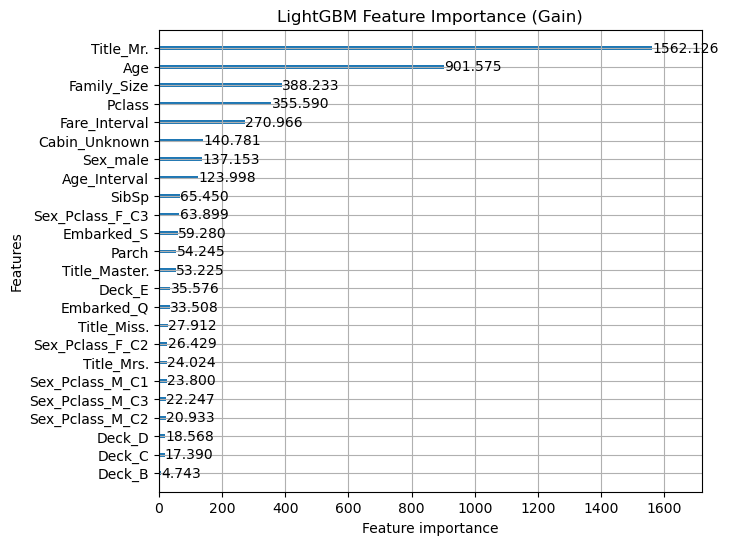

In [40]:
lgb.plot_importance(model, importance_type="gain", figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

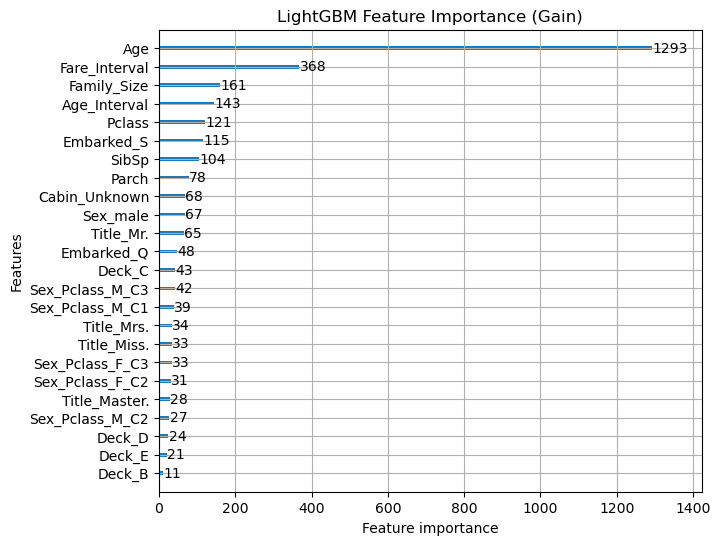

In [41]:
lgb.plot_importance(model, importance_type="split",  figsize=(7,6), title="LightGBM Feature Importance (Gain)")
plt.show()

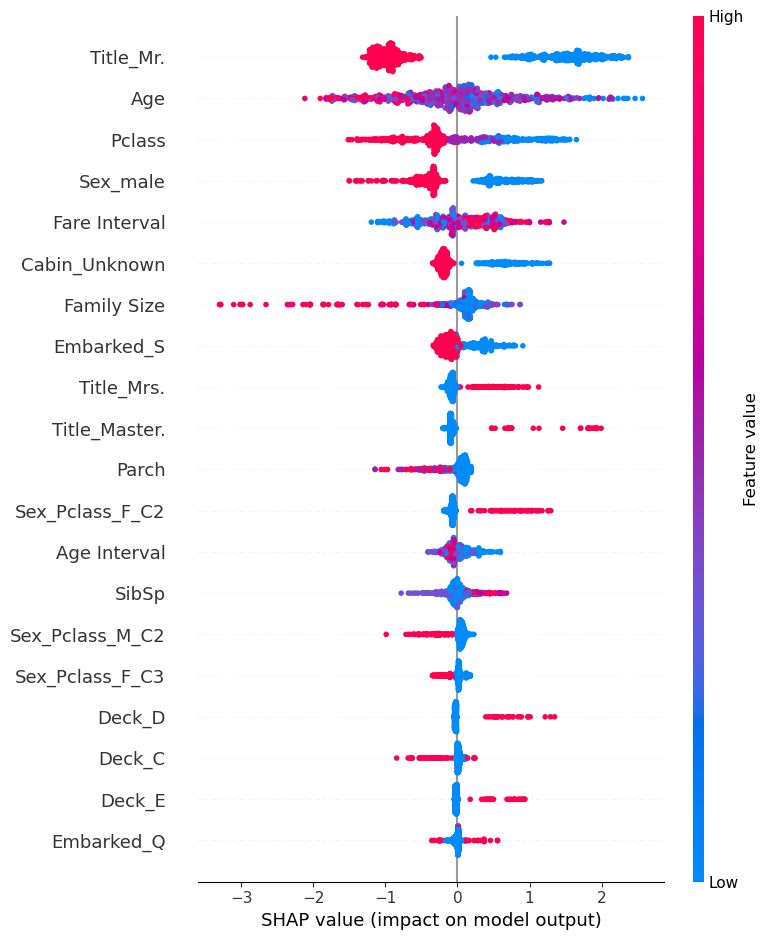

In [42]:
import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.explanation import *
shap_explain_model_on_batch(model, X_train, features)

In [43]:
#! pip install git+https://github.com/milesqli/iffnn.git 

# Explanation With My IFFNN

In [44]:
import torch
from iffnn import IFFNN

model = IFFNN(
    input_size=len(X_train.columns),
    num_classes=1,
    feature_names=X_train.columns.tolist(),  # Optional
    class_names=['Not Survived', 'Survived'],      # Optional
    hidden_sizes=[226, 113, 113,113,226], #None,            # Use default hidden layers
    device='auto'                 # Use CUDA if available
)

Using device: cuda


In [45]:
# Convert bool columns to int
X_train_NN_ = X_train.astype({col: 'int' for col in X_train.select_dtypes(include='bool').columns})

In [46]:
from sklearn.model_selection import train_test_split
X_train_NN,X_valid_NN,y_train_NN,y_valid_NN = train_test_split(X_train_NN_,y_train,test_size=0.05)

In [47]:
# Convert bool columns to int
X_test_NN = X_test.astype({col: 'int' for col in X_test.select_dtypes(include='bool').columns})

In [48]:
train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_train_NN.values, dtype=torch.float32), torch.tensor(y_train_NN.values, dtype=torch.float32)),
    batch_size=64,
    shuffle=True
)
valid_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_valid_NN.values, dtype=torch.float32), torch.tensor(y_valid_NN.values, dtype=torch.float32)),
    batch_size=64,
    shuffle=True
)


In [49]:
history = model.train_model(
    train_loader=train_loader,
    valid_loader=valid_loader,
    num_epochs=30, # Adjust as needed
    save_path='best_iffnn_model.pth' # Optional: saves the best model based on validation accuracy
)

Starting training for 30 epochs...
Epoch [10/30], Train Loss: 0.4185, Valid Loss: 0.2827, Valid Acc: 82.22%
Early stopping at epoch 11 (patience reached).
Training finished. Best validation accuracy: 88.89% at epoch 6
Total training time: 2.47 seconds
Loaded best model weights from epoch 6


In [50]:
explanations = model.explain(
    X_train_NN.values[:5],   # Your batch of input features
    top_n=5,          # Show top 5 features per class
    print_output=True # Print explanations to console
)

=====

--- Sample 0 (Predicted Probs: 'Not Survived': 79.10%, 'Survived': 20.90%) ---
=====
  --- Top Contributions towards Class 'Survived' (Positive)  with Probability 20.90% ---
    Rank 1: Feature 'Age' (value=29.0000) -> Contribution=0.9288
    Rank 2: Feature 'Title_Mr.' (value=1.0000) -> Contribution=-0.6389
    Rank 3: Feature 'Fare Interval' (value=2.0000) -> Contribution=0.6175
    Rank 4: Feature 'Sex_male' (value=1.0000) -> Contribution=-0.5562
    Rank 5: Feature 'Sex_Pclass_M_C2' (value=1.0000) -> Contribution=-0.5421
  --- Top Contributions towards Class 'Not Survived' (Negative)  with Probability 79.10% ---
    Rank 1: Feature 'Age' (value=29.0000) -> Contribution=-0.9288
    Rank 2: Feature 'Title_Mr.' (value=1.0000) -> Contribution=0.6389
    Rank 3: Feature 'Fare Interval' (value=2.0000) -> Contribution=-0.6175
    Rank 4: Feature 'Sex_male' (value=1.0000) -> Contribution=0.5562
    Rank 5: Feature 'Sex_Pclass_M_C2' (value=1.0000) -> Contribution=0.5421
=====

--- Sa

In [51]:

test_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.tensor(X_test_NN.values, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.int)),
    batch_size=64,
    shuffle=True
)

In [52]:
res = model.evaluate_model(test_loader)
score = res['test_accuracy']
all_model_results['IFFNN'] = score/100
print("IFFNN Test Score:", score)

Test Accuracy: 90.19%
IFFNN Test Score: 90.19138755980862


In [53]:
for mo, acc in all_model_results.items():
    print(f"Accuracy of {mo} is {acc*100:.2f}%")

Accuracy of LightGBM is 82.30%
Accuracy of IFFNN is 90.19%
